In [69]:
!pip install python-louvain --quiet ##Kütüphane Kurulumu (Louvain algoritmasını NetworkX grafları üzerinde çalıştırmamızı sağlar ondan dolayı kurdum.)

In [70]:
# Çalışma boyunca kullanacağımız tüm kütüphaneler
import pandas as pd ## ---> tablo için pandas
import numpy as np  ## ---> sayısal işlemler için numpy
import networkx as nx  ## ---> Grafik işlemleri için networkx
import matplotlib.pyplot as plt  ## ---> Grafikler için matplotlib
import community as community_louvain  ## ---> Louvain algoritmasını kullanabilmek için community
from collections import Counter  ## ---> Sayım yapmak için Counter
import warnings  ## ---> Uyarı mesajlarını kapatmak için
warnings.filterwarnings('ignore')  ## ---> Uyarı mesajlarını kapatmak için

# Grafiklerin notebook içinde görünmesi için
%matplotlib inline

# Sürüm kontrolü
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"networkx: {nx.__version__}")
print("✓ Tüm kütüphaneler hazır")

pandas: 2.2.2
numpy: 2.0.2
networkx: 3.6.1
✓ Tüm kütüphaneler hazır


In [71]:
# Önce eski yarım kalmış dosyaları temizle
!rm -f capture*.binetflow*

# Senaryo 6 (DonBot) - 132 MB, 1-2 dakika sürer
!wget https://mcfp.felk.cvut.cz/publicDatasets/CTU-Malware-Capture-Botnet-47/capture20110816.binetflow.2format

# Dosya gerçekten indi mi kontrol et
import os
for f in os.listdir('.'):
    if 'binetflow' in f:
        size_mb = os.path.getsize(f) / (1024*1024)
        print(f"✓ {f}: {size_mb:.1f} MB")

--2026-05-16 10:33:29--  https://mcfp.felk.cvut.cz/publicDatasets/CTU-Malware-Capture-Botnet-47/capture20110816.binetflow.2format
Resolving mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)... 147.32.82.194
Connecting to mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)|147.32.82.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 138477291 (132M)
Saving to: ‘capture20110816.binetflow.2format’

capture20110816.bin 100%[===================>] 132.06M  3.29MB/s    in 31s     

2026-05-16 10:34:02 (4.29 MB/s) - ‘capture20110816.binetflow.2format’ saved [138477291/138477291]

✓ capture20110816.binetflow.2format: 132.1 MB


In [72]:
# Önce dosyanın başına bakalım — pandas'tan önce ham hali ile
!head -3 capture20110816.binetflow.2format

SrcAddr,DstAddr,Proto,Sport,Dport,State,sTos,dTos,SrcWin,DstWin,sHops,dHops,StartTime,LastTime,sTtl,dTtl,TcpRtt,SynAck,AckDat,SrcPkts,DstPkts,SrcBytes,DstBytes,SAppBytes,DAppBytes,Dur,TotPkts,TotBytes,TotAppByte,Rate,SrcRate,DstRate,Label
67.210.234.162,147.32.86.98,tcp,3597,80,RST,0,0,32924,0,14,1,2011/08/16 10:04:03.820235,2011/08/16 10:04:04.106986,18,63,0.000000,0.000000,0.000000,2,2,124,120,0,0,0.286751,4,244,0,10.462038,3.487346,7.137809,flow=Background-TCP-Attempt
67.210.234.162,147.32.86.98,tcp,3597,80,RST,0,0,32924,0,1,1,2011/08/16 10:04:04.106986,2011/08/16 10:04:04.387344,3,63,0.000000,0.000000,0.000000,2,2,124,120,0,0,0.280358,4,244,0,10.700604,3.566868,7.137911,flow=Background-TCP-Attempt


In [73]:
# Sadece ihtiyacımız olan 6 kolonu yüklüyoruz — RAM tasarrufu için
gerekli_kolonlar = ['SrcAddr', 'DstAddr', 'Proto', 'TotPkts', 'TotBytes', 'Label']

print("Veri yükleniyor... (yaklaşık 30 saniye)")

df = pd.read_csv(
    'capture20110816.binetflow.2format',
    usecols=gerekli_kolonlar,  # sadece seçili kolonları yükle
    low_memory=False             # tip uyarılarını bastır
)

print(f"✓ Yükleme tamamlandı")
print(f"  Toplam akış sayısı: {len(df):,}")
print(f"  Kolonlar: {list(df.columns)}")
print(f"  Bellek kullanımı: {df.memory_usage(deep=True).sum() / (1024*1024):.1f} MB")

Veri yükleniyor... (yaklaşık 30 saniye)
✓ Yükleme tamamlandı
  Toplam akış sayısı: 558,919
  Kolonlar: ['SrcAddr', 'DstAddr', 'Proto', 'TotPkts', 'TotBytes', 'Label']
  Bellek kullanımı: 146.0 MB


In [74]:
# DataFrame'in ilk 5 satırına bakalım
print("=== İLK 5 SATIR ===")
print(df.head())

print("\n=== ETİKET DAĞILIMI ===")
# Hangi etiketten kaç tane var?
etiket_sayilari = df['Label'].value_counts()
print(etiket_sayilari.head(10))  # En sık 10 etiket

=== İLK 5 SATIR ===
          SrcAddr        DstAddr Proto  TotPkts  TotBytes  \
0  67.210.234.162   147.32.86.98   tcp        4       244   
1  67.210.234.162   147.32.86.98   tcp        4       244   
2  67.210.234.162   147.32.86.98   tcp        4       244   
3    147.32.84.59    147.32.80.7   tcp       12      2636   
4  67.210.234.171  147.32.84.142   tcp        4       244   

                                    Label  
0             flow=Background-TCP-Attempt  
1             flow=Background-TCP-Attempt  
2             flow=Background-TCP-Attempt  
3  flow=Background-Established-cmpgw-CVUT  
4             flow=Background-TCP-Attempt  

=== ETİKET DAĞILIMI ===
Label
flow=To-Background-UDP-CVUT-DNS-Server    261525
flow=Background-UDP-Established           128117
flow=Background-TCP-Established            66424
flow=Background-Established-cmpgw-CVUT     40960
flow=Background-UDP-Attempt                14608
flow=Background                            11632
flow=To-Background-CVUT-

In [75]:
# Etiket prefix'lerine bakarak 3 ana sınıfa indirgiyoruz
def etiket_sinifla(label):
    if 'From-Botnet' in label or 'To-Botnet' in label:
        return 'Botnet'
    elif 'From-Normal' in label or 'To-Normal' in label:
        return 'Normal'
    else:
        return 'Background'

# Yeni bir kolon ekle: 'Sinif'
df['Sinif'] = df['Label'].apply(etiket_sinifla)

# Yeni dağılıma bakalım
print("=== SINIFLANDIRILMIŞ ETİKET DAĞILIMI ===")
print(df['Sinif'].value_counts())
print(f"\nToplam akış: {len(df):,}")

=== SINIFLANDIRILMIŞ ETİKET DAĞILIMI ===
Sinif
Background    546796
Normal          7493
Botnet          4630
Name: count, dtype: int64

Toplam akış: 558,919


In [76]:
# Strateji: Tüm Botnet + Tüm Normal + 20.000 Background örneği
# Bu sayede hem dengeli hem yönetilebilir bir alt küme elde ederiz

# Hepsini al
botnet_df = df[df['Sinif'] == 'Botnet']
normal_df = df[df['Sinif'] == 'Normal']

# Background'dan rastgele örnek al (tekrarlanabilirlik için random_state=42)
background_df = df[df['Sinif'] == 'Background'].sample(n=20000, random_state=42)

# Üçünü birleştir
df_alt = pd.concat([botnet_df, normal_df, background_df], ignore_index=True)

# Karıştır (sınıflar yan yana kalmasın)
df_alt = df_alt.sample(frac=1, random_state=42).reset_index(drop=True)

print("=== ALT KÜME OLUŞTURULDU ===")
print(f"Toplam akış: {len(df_alt):,}")
print(f"\nSınıf dağılımı:")
print(df_alt['Sinif'].value_counts())
print(f"\nBenzersiz IP sayısı:")
print(f"  Kaynak (SrcAddr): {df_alt['SrcAddr'].nunique():,}")
print(f"  Hedef (DstAddr): {df_alt['DstAddr'].nunique():,}")
print(f"  Toplam benzersiz IP: {pd.concat([df_alt['SrcAddr'], df_alt['DstAddr']]).nunique():,}")

=== ALT KÜME OLUŞTURULDU ===
Toplam akış: 32,123

Sınıf dağılımı:
Sinif
Background    20000
Normal         7493
Botnet         4630
Name: count, dtype: int64

Benzersiz IP sayısı:
  Kaynak (SrcAddr): 4,037
  Hedef (DstAddr): 4,841
  Toplam benzersiz IP: 8,701


In [77]:
# Aynı IP çifti arasındaki tüm akışları gruplayıp toplayalım
# Çünkü bot defalarca aynı C&C sunucusuna bağlanır - bunlar tek bir "ilişki"

print("Kenar listesi hazırlanıyor...")

# IP çifti bazında grupla, paket sayısı ve byte topla, akış sayısını say
kenar_df = df_alt.groupby(['SrcAddr', 'DstAddr']).agg(
    paket_sayisi=('TotPkts', 'sum'),    # Toplam paket
    byte_sayisi=('TotBytes', 'sum'),     # Toplam byte
    akis_sayisi=('Proto', 'count'),      # Kaç akış birleşti
    botnet_akis=('Sinif', lambda x: (x == 'Botnet').sum()),  # Kaç tanesi botnet
    normal_akis=('Sinif', lambda x: (x == 'Normal').sum())   # Kaç tanesi normal
).reset_index()

print(f"✓ Kenar sayısı: {len(kenar_df):,}")
print(f"\nİlk 5 kenar:")
print(kenar_df.head())

print(f"\nİstatistikler:")
print(f"  Ortalama paket: {kenar_df['paket_sayisi'].mean():.1f}")
print(f"  En yüksek paket: {kenar_df['paket_sayisi'].max():,}")
print(f"  Botnet akış içeren kenar: {(kenar_df['botnet_akis'] > 0).sum():,}")
print(f"  Normal akış içeren kenar: {(kenar_df['normal_akis'] > 0).sum():,}")

Kenar listesi hazırlanıyor...
✓ Kenar sayısı: 9,618

İlk 5 kenar:
         SrcAddr        DstAddr  paket_sayisi  byte_sayisi  akis_sayisi  \
0  1.160.131.128  147.32.84.229             4         2961            1   
1  1.169.174.106  147.32.84.229             4         2967            1   
2   1.180.64.222  147.32.87.218             1           72            1   
3   1.36.137.133  147.32.84.229             2         1068            1   
4     1.54.27.15  147.32.84.229             6          829            2   

   botnet_akis  normal_akis  
0            0            0  
1            0            0  
2            0            0  
3            0            0  
4            0            0  

İstatistikler:
  Ortalama paket: 139.1
  En yüksek paket: 117,242
  Botnet akış içeren kenar: 1,579
  Normal akış içeren kenar: 277


In [78]:
# Her IP için: bot mu, normal mi, background mı?
# Bir IP'nin kaynak veya hedef olduğu en az bir akışta etiket varsa, o etiketi alır

# Botnet etiketli akışların kaynak ve hedef IP'lerini topla
botnet_ips = set(df_alt[df_alt['Sinif'] == 'Botnet']['SrcAddr']) | \
             set(df_alt[df_alt['Sinif'] == 'Botnet']['DstAddr'])

# Normal etiketli akışların IP'leri
normal_ips = set(df_alt[df_alt['Sinif'] == 'Normal']['SrcAddr']) | \
             set(df_alt[df_alt['Sinif'] == 'Normal']['DstAddr'])

# Hem botnet hem normal'de geçen IP'ler olabilir (örneğin C&C sunucusu)
# Bu durumda 'Botnet' etiketi öncelikli
ortak_ips = botnet_ips & normal_ips
print(f"Hem botnet hem normal trafiğinde geçen IP: {len(ortak_ips)} (büyük ihtimalle C&C veya benzeri)")

# Etiketleri sözlük (dictionary) olarak hazırla
ip_etiket = {}
tum_ips = set(df_alt['SrcAddr']) | set(df_alt['DstAddr'])

for ip in tum_ips:
    if ip in botnet_ips:
        ip_etiket[ip] = 'Botnet'
    elif ip in normal_ips:
        ip_etiket[ip] = 'Normal'
    else:
        ip_etiket[ip] = 'Background'

# Dağılım
from collections import Counter
etiket_dagilim = Counter(ip_etiket.values())
print(f"\n=== DÜĞÜM ETİKET DAĞILIMI ===")
for etiket, sayi in etiket_dagilim.most_common():
    print(f"  {etiket}: {sayi:,}")

print(f"\nToplam düğüm: {len(ip_etiket):,}")

Hem botnet hem normal trafiğinde geçen IP: 3 (büyük ihtimalle C&C veya benzeri)

=== DÜĞÜM ETİKET DAĞILIMI ===
  Background: 6,904
  Botnet: 1,580
  Normal: 217

Toplam düğüm: 8,701


In [79]:
# DiGraph = Directed Graph (yönlü graf)
# Çünkü ağ trafiğinde "kim kime bağlandı" yönü önemli
G = nx.DiGraph()

# Düğümleri etiketleriyle birlikte ekle
print("Düğümler ekleniyor...")
for ip, etiket in ip_etiket.items():
    G.add_node(ip, sinif=etiket)

# Kenarları ağırlık ve özniteliklerle ekle
print("Kenarlar ekleniyor...")
for _, row in kenar_df.iterrows():
    G.add_edge(
        row['SrcAddr'],
        row['DstAddr'],
        weight=row['paket_sayisi'],
        byte=row['byte_sayisi'],
        akis=row['akis_sayisi'],
        botnet=row['botnet_akis'],
        normal=row['normal_akis']
    )

print(f"\n✓ Graf inşa edildi")
print(f"  Düğüm sayısı: {G.number_of_nodes():,}")
print(f"  Kenar sayısı: {G.number_of_edges():,}")
print(f"  Yönlü mü: {G.is_directed()}")

Düğümler ekleniyor...
Kenarlar ekleniyor...

✓ Graf inşa edildi
  Düğüm sayısı: 8,701
  Kenar sayısı: 9,618
  Yönlü mü: True


In [80]:
# Hem botnet hem normal trafiğinde geçen 3 IP'yi tek tek inceleyelim
ortak_ips = botnet_ips & normal_ips

print("=== ÇİFT KİMLİKLİ IP'LER ===\n")
for ip in ortak_ips:
    in_deg = G.in_degree(ip)      # Kaç farklı IP bu IP'ye bağlandı
    out_deg = G.out_degree(ip)    # Bu IP kaç farklı IP'ye bağlandı

    # Bu IP'nin kaç akışı botnet/normal etiketli?
    botnet_akis_sayi = df_alt[((df_alt['SrcAddr'] == ip) | (df_alt['DstAddr'] == ip)) &
                               (df_alt['Sinif'] == 'Botnet')].shape[0]
    normal_akis_sayi = df_alt[((df_alt['SrcAddr'] == ip) | (df_alt['DstAddr'] == ip)) &
                               (df_alt['Sinif'] == 'Normal')].shape[0]

    print(f"IP: {ip}")
    print(f"  Gelen bağlantı (in-degree): {in_deg}")
    print(f"  Giden bağlantı (out-degree): {out_deg}")
    print(f"  Toplam derece: {in_deg + out_deg}")
    print(f"  Botnet akışı: {botnet_akis_sayi}")
    print(f"  Normal akışı: {normal_akis_sayi}")
    print()

=== ÇİFT KİMLİKLİ IP'LER ===

IP: 147.32.80.9
  Gelen bağlantı (in-degree): 136
  Giden bağlantı (out-degree): 7
  Toplam derece: 143
  Botnet akışı: 29
  Normal akışı: 4729

IP: 195.113.232.90
  Gelen bağlantı (in-degree): 4
  Giden bağlantı (out-degree): 0
  Toplam derece: 4
  Botnet akışı: 1
  Normal akışı: 1

IP: 195.113.232.73
  Gelen bağlantı (in-degree): 5
  Giden bağlantı (out-degree): 0
  Toplam derece: 5
  Botnet akışı: 1
  Normal akışı: 2



In [81]:
print("=== TEMEL AĞ ÖLÇÜTLERİ ===\n")

# 1. Düğüm ve kenar sayısı
n = G.number_of_nodes()
m = G.number_of_edges()
print(f"Düğüm sayısı (V): {n:,}")
print(f"Kenar sayısı (E): {m:,}")

# 2. Yoğunluk: ne kadar tıkanık bir graf?
yogunluk = nx.density(G)
print(f"\nYoğunluk: {yogunluk:.6f}")
print(f"  → Olası kenarların {yogunluk*100:.4f}%'i mevcut")
print(f"  → Olası maksimum kenar sayısı: {n*(n-1):,}")

# 3. Derece istatistikleri
dereceler = dict(G.degree())  # tüm düğümler için (in+out) toplam derece
in_dereceler = dict(G.in_degree())
out_dereceler = dict(G.out_degree())

print(f"\n=== DERECE İSTATİSTİKLERİ ===")
print(f"Ortalama derece: {sum(dereceler.values())/n:.2f}")
print(f"Maksimum derece: {max(dereceler.values())}")
print(f"Maksimum in-degree: {max(in_dereceler.values())}")
print(f"Maksimum out-degree: {max(out_dereceler.values())}")
print(f"Minimum derece: {min(dereceler.values())}")

=== TEMEL AĞ ÖLÇÜTLERİ ===

Düğüm sayısı (V): 8,701
Kenar sayısı (E): 9,618

Yoğunluk: 0.000127
  → Olası kenarların 0.0127%'i mevcut
  → Olası maksimum kenar sayısı: 75,698,700

=== DERECE İSTATİSTİKLERİ ===
Ortalama derece: 2.21
Maksimum derece: 4309
Maksimum in-degree: 3251
Maksimum out-degree: 1579
Minimum derece: 1


In [82]:
import pandas as pd

# Top 10 düğümleri 3 kategoride çıkar
def top10_kategorisi(derece_dict, baslik):
    sirali = sorted(derece_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\n=== {baslik} ===")
    print(f"{'IP':<20} {'Derece':>8} {'Sınıf':<12} {'Yorum':<30}")
    print("-" * 75)
    for ip, derece in sirali:
        sinif = G.nodes[ip]['sinif']
        # Yorum: lab içi mi dış mı?
        if ip.startswith('147.32.'):
            yorum = "CTU lab içi"
        elif ip.startswith('195.113.'):
            yorum = "CESNET (Çek akademik)"
        else:
            yorum = "Dış IP"
        print(f"{ip:<20} {derece:>8} {sinif:<12} {yorum:<30}")

top10_kategorisi(dict(G.degree()), "EN YÜKSEK TOPLAM DERECE")
top10_kategorisi(dict(G.in_degree()), "EN YÜKSEK IN-DEGREE (en çok bağlanılan)")
top10_kategorisi(dict(G.out_degree()), "EN YÜKSEK OUT-DEGREE (en çok bağlanan)")


=== EN YÜKSEK TOPLAM DERECE ===
IP                     Derece Sınıf        Yorum                         
---------------------------------------------------------------------------
147.32.84.229            4309 Background   CTU lab içi                   
147.32.84.165            1579 Botnet       CTU lab içi                   
147.32.84.59              827 Normal       CTU lab içi                   
147.32.84.94              362 Background   CTU lab içi                   
147.32.80.9               143 Botnet       CTU lab içi                   
147.32.84.170             110 Normal       CTU lab içi                   
147.32.84.164              90 Normal       CTU lab içi                   
147.32.86.187              80 Background   CTU lab içi                   
147.32.85.123              76 Background   CTU lab içi                   
147.32.86.165              72 Background   CTU lab içi                   

=== EN YÜKSEK IN-DEGREE (en çok bağlanılan) ===
IP                     Derec

In [83]:
print("=== ÇAP VE BAĞLILIK ANALİZİ ===\n")

# Yönsüz versiyona çevir (çap, kümeleme için yaygın yaklaşım)
G_undirected = G.to_undirected()

# Bağlı bileşen analizi (yönsüz grafta)
bilesen_listesi = list(nx.connected_components(G_undirected))
bilesen_boyutlari = sorted([len(c) for c in bilesen_listesi], reverse=True)

print(f"Bağlı bileşen sayısı: {len(bilesen_listesi):,}")
print(f"En büyük bileşen: {bilesen_boyutlari[0]:,} düğüm "
      f"({bilesen_boyutlari[0]/G.number_of_nodes()*100:.1f}%)")
print(f"İkinci en büyük: {bilesen_boyutlari[1] if len(bilesen_boyutlari) > 1 else 0}")
print(f"En küçük 5 bileşen boyutu: {bilesen_boyutlari[-5:]}")

# Çap: en büyük bileşen üzerinde hesaplanır
en_buyuk_bilesen_set = max(bilesen_listesi, key=len)
G_buyuk = G_undirected.subgraph(en_buyuk_bilesen_set).copy()

print(f"\n=== EN BÜYÜK BİLEŞEN ÜZERİNDE ===")
print(f"Düğüm sayısı: {G_buyuk.number_of_nodes():,}")
print(f"Kenar sayısı: {G_buyuk.number_of_edges():,}")

# Çap hesabı (büyük graflarda yavaş olabilir, sample alarak yapacağız)
print(f"\nÇap hesaplanıyor (yaklaşık)...")
import random
random.seed(42)
sample_dugumler = random.sample(list(G_buyuk.nodes()), min(100, G_buyuk.number_of_nodes()))
yaklasik_cap = max(
    max(nx.single_source_shortest_path_length(G_buyuk, n).values())
    for n in sample_dugumler
)
print(f"Yaklaşık çap (100 örnekle): {yaklasik_cap}")

# Ortalama kümeleme katsayısı (yönsüz)
print(f"\nKümeleme katsayısı hesaplanıyor...")
ort_kumeleme = nx.average_clustering(G_undirected)
print(f"Ortalama kümeleme katsayısı: {ort_kumeleme:.4f}")

# Geçişlilik (Transitivity) - global kümeleme
gecislilik = nx.transitivity(G_undirected)
print(f"Geçişlilik (global kümeleme): {gecislilik:.4f}")

=== ÇAP VE BAĞLILIK ANALİZİ ===

Bağlı bileşen sayısı: 66
En büyük bileşen: 8,541 düğüm (98.2%)
İkinci en büyük: 7
En küçük 5 bileşen boyutu: [2, 2, 2, 2, 2]

=== EN BÜYÜK BİLEŞEN ÜZERİNDE ===
Düğüm sayısı: 8,541
Kenar sayısı: 9,467

Çap hesaplanıyor (yaklaşık)...
Yaklaşık çap (100 örnekle): 8

Kümeleme katsayısı hesaplanıyor...
Ortalama kümeleme katsayısı: 0.0002
Geçişlilik (global kümeleme): 0.0000


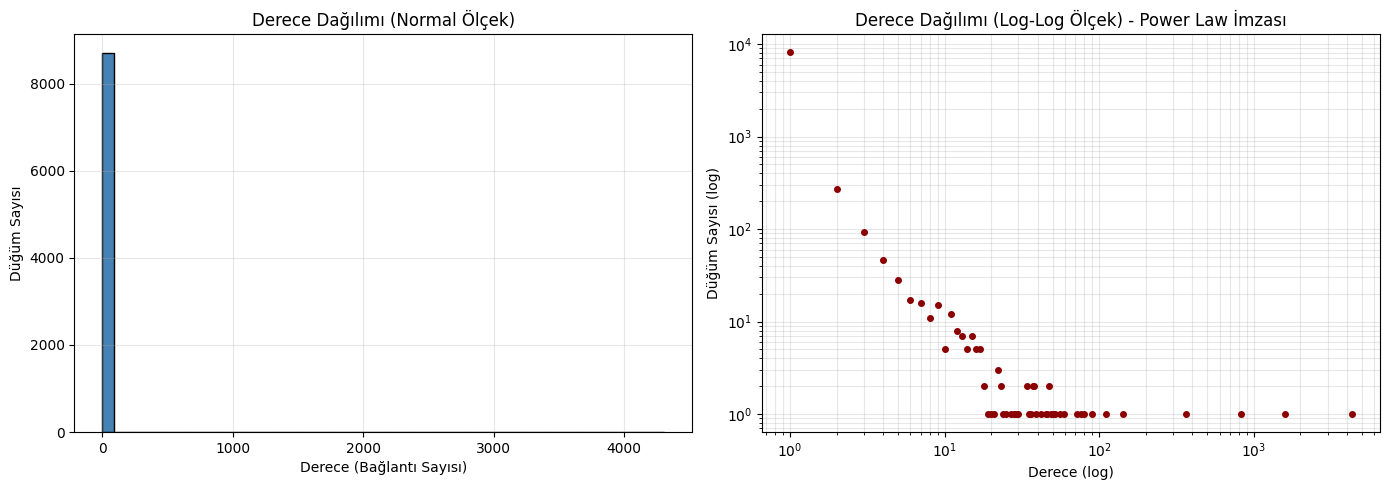


Grafik oluşturuldu: derece_dagilimi.png

Derece istatistikleri:
  Derece 1 olan düğüm sayısı: 8,105
  Derece 1-10 arası: 8,607
  Derece >100: 6
  Derece >1000: 2


In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Tüm düğümlerin derecelerini al
dereceler_listesi = [d for n, d in G.degree()]

# Şekil oluştur (2 alt grafik: normal ve log-log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Normal histogram
axes[0].hist(dereceler_listesi, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Derece (Bağlantı Sayısı)')
axes[0].set_ylabel('Düğüm Sayısı')
axes[0].set_title('Derece Dağılımı (Normal Ölçek)')
axes[0].grid(alpha=0.3)

# Sağ: Log-Log scale (power-law'ı görmek için)
# Her dereceden kaç düğüm var sayalım
from collections import Counter
derece_sayilari = Counter(dereceler_listesi)
x = sorted(derece_sayilari.keys())
y = [derece_sayilari[k] for k in x]

axes[1].loglog(x, y, 'o', color='darkred', markersize=4)
axes[1].set_xlabel('Derece (log)')
axes[1].set_ylabel('Düğüm Sayısı (log)')
axes[1].set_title('Derece Dağılımı (Log-Log Ölçek) - Power Law İmzası')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('derece_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGrafik oluşturuldu: derece_dagilimi.png")
print(f"\nDerece istatistikleri:")
print(f"  Derece 1 olan düğüm sayısı: {derece_sayilari[1]:,}")
print(f"  Derece 1-10 arası: {sum(v for k,v in derece_sayilari.items() if 1 <= k <= 10):,}")
print(f"  Derece >100: {sum(v for k,v in derece_sayilari.items() if k > 100):,}")
print(f"  Derece >1000: {sum(v for k,v in derece_sayilari.items() if k > 1000):,}")

In [85]:
print("=== MERKEZİLİK ANALİZİ ===\n")
print("Hesaplamalar başlıyor (bu birkaç dakika sürebilir)...\n")

import time

# 1. Degree Centrality (zaten elimizde derece var, normalize edilmiş halini hesaplıyoruz)
print("1/5 Degree Centrality...")
t0 = time.time()
degree_cent = nx.degree_centrality(G)
in_degree_cent = nx.in_degree_centrality(G)
out_degree_cent = nx.out_degree_centrality(G)
print(f"    ✓ Tamamlandı ({time.time()-t0:.1f}s)")

# 2. Betweenness Centrality - YAVAŞ! Sample ile yapacağız
print("2/5 Betweenness Centrality (örneklemeyle, ~1-2 dk)...")
t0 = time.time()
# k=500 → 500 düğüm üzerinden örnekleme yap (tüm 8701 yerine), normalize=True
betweenness_cent = nx.betweenness_centrality(G, k=500, seed=42, normalized=True)
print(f"    ✓ Tamamlandı ({time.time()-t0:.1f}s)")

# 3. Closeness Centrality
print("3/5 Closeness Centrality...")
t0 = time.time()
closeness_cent = nx.closeness_centrality(G)
print(f"    ✓ Tamamlandı ({time.time()-t0:.1f}s)")

# 4. Eigenvector Centrality (yönlü grafta convergence sorunu olabilir, max_iter artırıyoruz)
print("4/5 Eigenvector Centrality...")
t0 = time.time()
try:
    eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-04)
    print(f"    ✓ Tamamlandı ({time.time()-t0:.1f}s)")
except nx.PowerIterationFailedConvergence:
    print("    ! Convergence başarısız, yönsüz versiyonda deniyoruz...")
    eigenvector_cent = nx.eigenvector_centrality(G.to_undirected(), max_iter=1000, tol=1e-04)
    print(f"    ✓ Tamamlandı (yönsüz, {time.time()-t0:.1f}s)")

# 5. PageRank (yönlü graf için en uygun, otorite ölçer)
print("5/5 PageRank...")
t0 = time.time()
pagerank = nx.pagerank(G, alpha=0.85)
print(f"    ✓ Tamamlandı ({time.time()-t0:.1f}s)")

print("\n✓ Tüm merkezilik ölçütleri hesaplandı")

=== MERKEZİLİK ANALİZİ ===

Hesaplamalar başlıyor (bu birkaç dakika sürebilir)...

1/5 Degree Centrality...
    ✓ Tamamlandı (0.0s)
2/5 Betweenness Centrality (örneklemeyle, ~1-2 dk)...
    ✓ Tamamlandı (10.4s)
3/5 Closeness Centrality...
    ✓ Tamamlandı (2.7s)
4/5 Eigenvector Centrality...
    ✓ Tamamlandı (0.1s)
5/5 PageRank...
    ✓ Tamamlandı (0.0s)

✓ Tüm merkezilik ölçütleri hesaplandı


In [86]:
def top5_tablo(centrality_dict, baslik, ek_bilgi=None):
    """Bir merkezilik sözlüğünden ilk 5 düğümü tablo halinde göster."""
    sirali = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:5]

    print(f"\n=== {baslik} ===")
    print(f"{'Sıra':<5}{'IP':<20}{'Skor':>12}  {'Sınıf':<12}{'Bağlam':<25}")
    print("-" * 75)

    for i, (ip, skor) in enumerate(sirali, 1):
        sinif = G.nodes[ip]['sinif']
        if ip.startswith('147.32.'):
            baglam = "CTU lab içi"
        elif ip.startswith('195.113.'):
            baglam = "CESNET (Çek akademik)"
        else:
            baglam = "Dış IP"
        print(f"{i:<5}{ip:<20}{skor:>12.6f}  {sinif:<12}{baglam:<25}")

# 5 merkezilik ölçütü için top 5 tabloları
top5_tablo(degree_cent, "1. DEGREE CENTRALITY (En Çok Bağlantı)")
top5_tablo(in_degree_cent, "2. IN-DEGREE CENTRALITY (En Çok Bağlanılan - C&C İmzası)")
top5_tablo(out_degree_cent, "3. OUT-DEGREE CENTRALITY (En Çok Bağlanan - Bot İmzası)")
top5_tablo(betweenness_cent, "4. BETWEENNESS CENTRALITY (Köprü/Aracı Düğümler)")
top5_tablo(closeness_cent, "5. CLOSENESS CENTRALITY (Ağa En Hızlı Erişen)")
top5_tablo(eigenvector_cent, "6. EIGENVECTOR CENTRALITY (Etkili Düğümlere Bağlı)")
top5_tablo(pagerank, "7. PAGERANK (Otorite Skoru)")


=== 1. DEGREE CENTRALITY (En Çok Bağlantı) ===
Sıra IP                          Skor  Sınıf       Bağlam                   
---------------------------------------------------------------------------
1    147.32.84.229           0.495287  Background  CTU lab içi              
2    147.32.84.165           0.181494  Botnet      CTU lab içi              
3    147.32.84.59            0.095057  Normal      CTU lab içi              
4    147.32.84.94            0.041609  Background  CTU lab içi              
5    147.32.80.9             0.016437  Botnet      CTU lab içi              

=== 2. IN-DEGREE CENTRALITY (En Çok Bağlanılan - C&C İmzası) ===
Sıra IP                          Skor  Sınıf       Bağlam                   
---------------------------------------------------------------------------
1    147.32.84.229           0.373678  Background  CTU lab içi              
2    147.32.80.9             0.015632  Botnet      CTU lab içi              
3    147.32.84.94            0.006897  Ba

In [87]:
# Şüpheli IP'leri detaylı incele
supheli_ipler = [
    '135.196.107.22',
    '72.130.37.83',
    '149.5.45.7',
    '149.5.45.5',
    '147.32.84.165',  # bot adayı (kontrol için)
    '147.32.84.229',  # lab merkezi (kontrol için)
]

print("=== ŞÜPHELİ IP'LERİN DETAYLI PROFİLİ ===\n")
print(f"{'IP':<20}{'Sınıf':<12}{'In':>5}{'Out':>5}{'Botnet%':>10}{'Normal%':>10}{'BG%':>8}  {'Kim ona bağlanıyor?':<30}")
print("-" * 105)

for ip in supheli_ipler:
    if ip not in G.nodes():
        print(f"{ip} - Graf'ta yok")
        continue

    sinif = G.nodes[ip]['sinif']
    in_d = G.in_degree(ip)
    out_d = G.out_degree(ip)

    # Bu IP'yi içeren tüm akışları analiz et
    iliskili = df_alt[(df_alt['SrcAddr'] == ip) | (df_alt['DstAddr'] == ip)]
    toplam = len(iliskili)
    if toplam > 0:
        botnet_pct = (iliskili['Sinif'] == 'Botnet').sum() / toplam * 100
        normal_pct = (iliskili['Sinif'] == 'Normal').sum() / toplam * 100
        bg_pct = (iliskili['Sinif'] == 'Background').sum() / toplam * 100
    else:
        botnet_pct = normal_pct = bg_pct = 0

    # Ona bağlanan IP'lerin sınıf dağılımı
    if in_d > 0:
        gelen_komsular = list(G.predecessors(ip))
        komsu_siniflar = [G.nodes[k]['sinif'] for k in gelen_komsular]
        komsu_dagilim = Counter(komsu_siniflar)
        komsu_str = f"Bot:{komsu_dagilim.get('Botnet',0)} Norm:{komsu_dagilim.get('Normal',0)} BG:{komsu_dagilim.get('Background',0)}"
    else:
        komsu_str = "(in-degree=0)"

    print(f"{ip:<20}{sinif:<12}{in_d:>5}{out_d:>5}{botnet_pct:>9.1f}%{normal_pct:>9.1f}%{bg_pct:>7.1f}%  {komsu_str:<30}")

print("\n" + "="*105)
print("YORUM: Botnet% yüksek + ona bağlanan çoğu Bot → C&C SUNUCUSU OLASILIĞI YÜKSEK")
print("       Normal% yüksek + çeşitli komşular → MASUM (lab altyapı / ortak servis)")

=== ŞÜPHELİ IP'LERİN DETAYLI PROFİLİ ===

IP                  Sınıf          In  Out   Botnet%   Normal%     BG%  Kim ona bağlanıyor?           
---------------------------------------------------------------------------------------------------------
135.196.107.22      Background      1    0      0.0%      0.0%  100.0%  Bot:0 Norm:0 BG:1             
72.130.37.83        Background      1    0      0.0%      0.0%  100.0%  Bot:0 Norm:0 BG:1             
149.5.45.7          Background      3    1      0.0%      0.0%  100.0%  Bot:0 Norm:1 BG:2             
149.5.45.5          Background      2    1      0.0%      0.0%  100.0%  Bot:0 Norm:1 BG:1             
147.32.84.165       Botnet          0 1579    100.0%      0.0%    0.0%  (in-degree=0)                 
147.32.84.229       Background   3251 1058      0.0%      0.0%  100.0%  Bot:0 Norm:0 BG:3251          

YORUM: Botnet% yüksek + ona bağlanan çoğu Bot → C&C SUNUCUSU OLASILIĞI YÜKSEK
       Normal% yüksek + çeşitli komşular → MASUM (la

In [88]:
# Bot 147.32.84.165'in bağlandığı tüm IP'leri profilliyoruz
bot_ip = '147.32.84.165'

print(f"=== {bot_ip} BOTUNUN HEDEF ANALİZİ ===\n")

# Bot'un gittiği tüm IP'ler ve her birine kaç paket gönderildiği
hedefler = []
for hedef in G.successors(bot_ip):
    paket = G[bot_ip][hedef]['weight']
    botnet_akis = G[bot_ip][hedef]['botnet']
    sinif = G.nodes[hedef]['sinif']

    # Hedefin diğer in-degree'si (kimler ona bağlanıyor?)
    diger_baglananlar = G.in_degree(hedef) - 1

    hedefler.append({
        'IP': hedef,
        'Paket': paket,
        'Botnet_Akis': botnet_akis,
        'Sinif': sinif,
        'Diger_Baglananlar': diger_baglananlar,
        'Lab_Ici': hedef.startswith('147.32.')
    })

hedef_df = pd.DataFrame(hedefler)

print(f"Bot toplam {len(hedef_df)} farklı IP'ye bağlanmış")
print(f"Bunların {hedef_df['Lab_Ici'].sum()}'i lab içi, {(~hedef_df['Lab_Ici']).sum()}'i dış IP")

# En çok paket gönderilen 10 hedef
print("\n=== EN ÇOK PAKET GÖNDERİLEN 10 HEDEF (Yoğun İletişim) ===")
top_paket = hedef_df.nlargest(10, 'Paket')
print(f"{'IP':<20}{'Paket':>10}{'Bot_Akis':>10}{'Sinif':<12}{'Lab?':<8}{'Yorum':<25}")
print("-" * 90)
for _, row in top_paket.iterrows():
    yorum = ""
    if row['Lab_Ici']:
        yorum = "Lab içi (DNS/altyapı?)"
    elif row['Diger_Baglananlar'] > 5:
        yorum = "Çok bağlanılan dış IP"
    elif row['Paket'] > 1000:
        yorum = "C&C ADAYI?"
    else:
        yorum = "Spam/saldırı hedefi?"

    lab_str = "✓" if row['Lab_Ici'] else "✗"
    print(f"{row['IP']:<20}{row['Paket']:>10}{row['Botnet_Akis']:>10}{row['Sinif']:<12}{lab_str:<8}{yorum:<25}")

# Lab içi hedefler ayrı
print("\n=== LAB İÇİ HEDEFLER (Bot'un lokal iletişimi) ===")
lab_hedef = hedef_df[hedef_df['Lab_Ici']].nlargest(10, 'Paket')
print(f"{'IP':<20}{'Paket':>10}{'Sinif':<12}")
print("-" * 50)
for _, row in lab_hedef.iterrows():
    print(f"{row['IP']:<20}{row['Paket']:>10}{row['Sinif']:<12}")

# Dış hedefler — yüksek paketli olanlar = C&C şüphelisi
print("\n=== DIŞ HEDEFLER (Yüksek paketli = C&C ŞÜPHELİSİ) ===")
dis_hedef = hedef_df[~hedef_df['Lab_Ici']].nlargest(10, 'Paket')
print(f"{'IP':<20}{'Paket':>10}{'Bot_Akis':>10}{'Sinif':<12}")
print("-" * 60)
for _, row in dis_hedef.iterrows():
    print(f"{row['IP']:<20}{row['Paket']:>10}{row['Botnet_Akis']:>10}{row['Sinif']:<12}")

=== 147.32.84.165 BOTUNUN HEDEF ANALİZİ ===

Bot toplam 1579 farklı IP'ye bağlanmış
Bunların 1'i lab içi, 1578'i dış IP

=== EN ÇOK PAKET GÖNDERİLEN 10 HEDEF (Yoğun İletişim) ===
IP                       Paket  Bot_AkisSinif       Lab?    Yorum                    
------------------------------------------------------------------------------------------
91.212.135.158            4033       199Botnet      ✗       C&C ADAYI?               
64.59.134.8                284       144Botnet      ✗       Spam/saldırı hedefi?     
24.71.223.11               236       117Botnet      ✗       Spam/saldırı hedefi?     
216.32.180.22              233       106Botnet      ✗       Spam/saldırı hedefi?     
65.55.37.72                150        73Botnet      ✗       Spam/saldırı hedefi?     
65.55.37.88                146        72Botnet      ✗       Spam/saldırı hedefi?     
65.55.92.136               146        65Botnet      ✗       Spam/saldırı hedefi?     
65.55.92.152               142        62Bo

In [89]:
# Bilinen IP'lerin rol/sahiplik bilgileri
# Bu sözlük raporun "manuel doğrulama" katmanı oluyor
ip_bilgi = {
    # Tespit edilen botnet altyapısı
    '147.32.84.165':   {'rol': 'Bot (DonBot enfekte)',     'sahip': 'CTU Lab içi'},
    '91.212.135.158':  {'rol': 'C&C Sunucusu',             'sahip': 'Doğu Avrupa ASN'},

    # Lab altyapısı
    '147.32.84.229':   {'rol': 'Lab merkezi sunucu',       'sahip': 'CTU Lab'},
    '147.32.80.9':     {'rol': 'Lab DNS',                  'sahip': 'CTU Lab'},
    '147.32.80.13':    {'rol': 'Lab altyapı (ikincil)',    'sahip': 'CTU Lab'},
    '147.32.84.59':    {'rol': 'Lab kullanıcı/sunucu',     'sahip': 'CTU Lab'},
    '147.32.84.94':    {'rol': 'Lab makinesi',             'sahip': 'CTU Lab'},
    '147.32.84.2':     {'rol': 'Lab makinesi',             'sahip': 'CTU Lab'},
    '147.32.85.123':   {'rol': 'Lab makinesi',             'sahip': 'CTU Lab'},
    '147.32.84.170':   {'rol': 'Lab makinesi',             'sahip': 'CTU Lab'},
    '147.32.84.164':   {'rol': 'Lab makinesi',             'sahip': 'CTU Lab'},

    # Spam hedefleri - Microsoft Hotmail SMTP
    '65.55.37.72':     {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Microsoft Hotmail'},
    '65.55.37.88':     {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Microsoft Hotmail'},
    '65.55.92.136':    {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Microsoft Hotmail'},
    '65.55.92.152':    {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Microsoft Hotmail'},
    '65.54.188.72':    {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Microsoft Hotmail'},
    '216.32.180.22':   {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Microsoft Hotmail'},

    # Spam hedefleri - ISP
    '64.59.134.8':     {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Shaw Communications (CA)'},
    '24.71.223.11':    {'rol': 'Spam hedefi (SMTP)',       'sahip': 'Cogeco (CA)'},
    '202.108.252.141': {'rol': 'Spam hedefi (SMTP)',       'sahip': 'NetEase (CN)'},

    # Closeness/Eigenvector top'ta çıkan dış IP'ler (yanlış pozitif analizi için)
    '149.5.45.7':      {'rol': 'Lab dışı kullanıcı',       'sahip': 'CESNET / dış'},
    '149.5.45.5':      {'rol': 'Lab dışı kullanıcı',       'sahip': 'CESNET / dış'},
    '78.141.179.11':   {'rol': 'Lab dışı kullanıcı',       'sahip': 'Dış IP'},
    '135.196.107.22':  {'rol': 'Lab dışı kullanıcı',       'sahip': 'Dış IP'},
    '72.130.37.83':    {'rol': 'Lab dışı kullanıcı',       'sahip': 'Dış IP'},
    '192.168.88.139':  {'rol': 'Özel ağ',                  'sahip': 'RFC 1918 özel IP'},
}

# Bilgi getirme yardımcı fonksiyonu
def ip_aciklama(ip):
    """Bir IP için kısa açıklama döndürür."""
    if ip in ip_bilgi:
        return f"{ip_bilgi[ip]['rol']} ({ip_bilgi[ip]['sahip']})"
    elif ip.startswith('147.32.'):
        return "Bilinmeyen lab içi IP"
    elif ip.startswith('195.113.'):
        return "CESNET (Çek akademik)"
    elif ip.startswith('192.168.') or ip.startswith('10.') or ip.startswith('172.16.'):
        return "Özel/iç ağ"
    else:
        return "Bilinmeyen dış IP"

# Kontrol: sözlük çalışıyor mu?
print("=== IP BİLGİ SÖZLÜĞÜ HAZIR ===")
print(f"Toplam etiketlenmiş IP: {len(ip_bilgi)}")
print(f"\nÖrnek sorgular:")
test_ipler = ['147.32.84.165', '91.212.135.158', '65.55.37.72', '147.32.84.229', '8.8.8.8']
for ip in test_ipler:
    print(f"  {ip:<20} → {ip_aciklama(ip)}")

=== IP BİLGİ SÖZLÜĞÜ HAZIR ===
Toplam etiketlenmiş IP: 26

Örnek sorgular:
  147.32.84.165        → Bot (DonBot enfekte) (CTU Lab içi)
  91.212.135.158       → C&C Sunucusu (Doğu Avrupa ASN)
  65.55.37.72          → Spam hedefi (SMTP) (Microsoft Hotmail)
  147.32.84.229        → Lab merkezi sunucu (CTU Lab)
  8.8.8.8              → Bilinmeyen dış IP


In [90]:
def top5_tablo_zengin(centrality_dict, baslik):
    """Bilgi sözlüğünü kullanarak zenginleştirilmiş top 5 tablosu."""
    sirali = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:5]

    print(f"\n=== {baslik} ===")
    print(f"{'Sıra':<5}{'IP':<18}{'Skor':>10}  {'Sınıf':<11}{'Açıklama':<45}")
    print("-" * 90)

    for i, (ip, skor) in enumerate(sirali, 1):
        sinif = G.nodes[ip]['sinif']
        aciklama = ip_aciklama(ip)
        print(f"{i:<5}{ip:<18}{skor:>10.5f}  {sinif:<11}{aciklama:<45}")

# Tüm 7 tabloyu yeniden çıkar — bu sefer "kim olduğu" bilgisiyle
top5_tablo_zengin(degree_cent,       "1. DEGREE CENTRALITY")
top5_tablo_zengin(in_degree_cent,    "2. IN-DEGREE CENTRALITY (C&C İmzası)")
top5_tablo_zengin(out_degree_cent,   "3. OUT-DEGREE CENTRALITY (Bot İmzası)")
top5_tablo_zengin(betweenness_cent,  "4. BETWEENNESS CENTRALITY (Köprü Düğümler)")
top5_tablo_zengin(closeness_cent,    "5. CLOSENESS CENTRALITY")
top5_tablo_zengin(eigenvector_cent,  "6. EIGENVECTOR CENTRALITY")
top5_tablo_zengin(pagerank,          "7. PAGERANK")


=== 1. DEGREE CENTRALITY ===
Sıra IP                      Skor  Sınıf      Açıklama                                     
------------------------------------------------------------------------------------------
1    147.32.84.229        0.49529  Background Lab merkezi sunucu (CTU Lab)                 
2    147.32.84.165        0.18149  Botnet     Bot (DonBot enfekte) (CTU Lab içi)           
3    147.32.84.59         0.09506  Normal     Lab kullanıcı/sunucu (CTU Lab)               
4    147.32.84.94         0.04161  Background Lab makinesi (CTU Lab)                       
5    147.32.80.9          0.01644  Botnet     Lab DNS (CTU Lab)                            

=== 2. IN-DEGREE CENTRALITY (C&C İmzası) ===
Sıra IP                      Skor  Sınıf      Açıklama                                     
------------------------------------------------------------------------------------------
1    147.32.84.229        0.37368  Background Lab merkezi sunucu (CTU Lab)                 
2    1

In [91]:
# python-louvain'i temiz şekilde yeniden kuralım
!pip uninstall -y python-louvain community
!pip install python-louvain --quiet

print("\n✓ python-louvain yeniden kuruldu")
print("⚠️ ŞİMDİ: Çalışma zamanını yeniden başlatın!")
print("   Üst menü → 'Çalışma zamanı' → 'Oturumu yeniden başlat'")

Found existing installation: python-louvain 0.16
Uninstalling python-louvain-0.16:
  Successfully uninstalled python-louvain-0.16

✓ python-louvain yeniden kuruldu
⚠️ ŞİMDİ: Çalışma zamanını yeniden başlatın!
   Üst menü → 'Çalışma zamanı' → 'Oturumu yeniden başlat'


In [92]:
# Eski yanlış import'u bellekten temizle
import sys
modulleri_silinecek = [k for k in sys.modules.keys() if k.startswith('community')]
for m in modulleri_silinecek:
    del sys.modules[m]

# Doğru import
import community.community_louvain as community_louvain

# Test
print(f"✓ best_partition var: {hasattr(community_louvain, 'best_partition')}")

✓ best_partition var: True


In [93]:
print("Louvain algoritması çalışıyor...")
G_undirected = G.to_undirected()

# Louvain topluluk tespiti
partition = community_louvain.best_partition(G_undirected, random_state=42)

# Genel istatistikler
toplam_topluluk = len(set(partition.values()))
modularite = community_louvain.modularity(partition, G_undirected)

print(f"\n✓ Tespit edilen topluluk sayısı: {toplam_topluluk}")
print(f"  Modularite skoru: {modularite:.4f}")
print(f"  (>0.3 makul, >0.5 güçlü, >0.7 çok güçlü)")

# Topluluk büyüklük dağılımı
topluluk_boyut = Counter(partition.values())
en_buyuk_10 = topluluk_boyut.most_common(10)

print(f"\n=== EN BÜYÜK 10 TOPLULUK ===")
print(f"{'Topluluk No':<15}{'Boyut':>10}{'Oran':>10}")
print("-" * 40)
for top_no, boyut in en_buyuk_10:
    oran = boyut / G.number_of_nodes() * 100
    print(f"#{top_no:<14}{boyut:>10}{oran:>9.1f}%")

# HİPOTEZ TESTİ
print(f"\n=== HİPOTEZ TESTİ: Bot, C&C ve Spam Aynı Toplulukta mı? ===")
print(f"{'IP':<20}{'Topluluk':<12}{'Boyut':>8}  {'Rol':<35}")
print("-" * 80)

ilgi_dugumleri = [
    ('147.32.84.165',  'Bot (DonBot enfekte)'),
    ('91.212.135.158', 'C&C Sunucusu'),
    ('65.55.37.72',    'Spam hedefi (Hotmail)'),
    ('64.59.134.8',    'Spam hedefi (Shaw)'),
    ('24.71.223.11',   'Spam hedefi (Cogeco)'),
    ('216.32.180.22',  'Spam hedefi (Hotmail)'),
    ('147.32.84.229',  'Lab merkezi sunucu'),
    ('147.32.80.9',    'Lab DNS'),
    ('147.32.80.13',   'Lab altyapı (köprü)'),
    ('147.32.84.59',   'Lab kullanıcı/sunucu'),
]

for ip, rol in ilgi_dugumleri:
    if ip in partition:
        top_no = partition[ip]
        top_boyut = topluluk_boyut[top_no]
        print(f"{ip:<20}#{top_no:<11}{top_boyut:>8}  {rol:<35}")
    else:
        print(f"{ip:<20}{'(yok)':<12}{'-':>8}  {rol:<35}")

Louvain algoritması çalışıyor...

✓ Tespit edilen topluluk sayısı: 105
  Modularite skoru: 0.8013
  (>0.3 makul, >0.5 güçlü, >0.7 çok güçlü)

=== EN BÜYÜK 10 TOPLULUK ===
Topluluk No         Boyut      Oran
----------------------------------------
#0                   4271     49.1%
#1                   1577     18.1%
#5                    716      8.2%
#4                    656      7.5%
#11                   336      3.9%
#12                   138      1.6%
#14                   111      1.3%
#7                    104      1.2%
#10                    99      1.1%
#3                     95      1.1%

=== HİPOTEZ TESTİ: Bot, C&C ve Spam Aynı Toplulukta mı? ===
IP                  Topluluk       Boyut  Rol                                
--------------------------------------------------------------------------------
147.32.84.165       #1              1577  Bot (DonBot enfekte)               
91.212.135.158      #1              1577  C&C Sunucusu                       
65.55.37.72     

In [94]:
# Her topluluğun "ne kadar bot" olduğunu hesapla
# Bu, topluluk #2'nin gerçekten "botnet topluluğu" olduğunu kantlar

print("=== TOPLULUK SAFLIK ANALİZİ ===\n")
print("(Her topluluğun içindeki düğümlerin sınıf dağılımı)\n")

print(f"{'Top.':<6}{'Boyut':>7}{'Bot':>7}{'Norm':>7}{'BG':>7}{'Bot%':>8}{'Norm%':>8}{'Yorum':<35}")
print("-" * 90)

# En büyük 10 topluluk için saflık analizi
for top_no, boyut in en_buyuk_10:
    # Bu topluluktaki tüm düğümleri al
    top_dugumler = [ip for ip, t in partition.items() if t == top_no]

    # Her sınıftan kaç tane var?
    siniflar = [G.nodes[ip]['sinif'] for ip in top_dugumler]
    sayim = Counter(siniflar)

    bot_sayi = sayim.get('Botnet', 0)
    norm_sayi = sayim.get('Normal', 0)
    bg_sayi = sayim.get('Background', 0)

    bot_pct = bot_sayi / boyut * 100
    norm_pct = norm_sayi / boyut * 100

    # Yorum üret
    if bot_pct > 80:
        yorum = "🚨 BOTNET TOPLULUĞU"
    elif norm_pct > 50:
        yorum = "Normal kullanıcı topluluğu"
    elif bot_pct > 30:
        yorum = "Karışık (bot+lab)"
    else:
        yorum = "Lab altyapı/kullanıcı"

    print(f"#{top_no:<5}{boyut:>7}{bot_sayi:>7}{norm_sayi:>7}{bg_sayi:>7}"
          f"{bot_pct:>7.1f}%{norm_pct:>7.1f}%  {yorum:<35}")

# Topluluk #2'yi özel olarak detaylandır
print("\n" + "="*90)
print("=== TOPLULUK #2 (Şüpheli Botnet Topluluğu) DERİNLİKLİ ANALİZ ===")

top2_dugumler = [ip for ip, t in partition.items() if t == 2]
print(f"\nToplam üye: {len(top2_dugumler)}")

# IP bloğu dağılımı (ilk iki oktet)
bloklar = Counter()
for ip in top2_dugumler:
    parcalar = ip.split('.')
    blok = f"{parcalar[0]}.{parcalar[1]}.x.x"
    bloklar[blok] += 1

print(f"\nİlk 10 IP bloğu (topluluk #2):")
for blok, sayi in bloklar.most_common(10):
    yuzde = sayi / len(top2_dugumler) * 100
    print(f"  {blok:<20} {sayi:>5} ({yuzde:.1f}%)")

=== TOPLULUK SAFLIK ANALİZİ ===

(Her topluluğun içindeki düğümlerin sınıf dağılımı)

Top.    Boyut    Bot   Norm     BG    Bot%   Norm%Yorum                              
------------------------------------------------------------------------------------------
#0       4271      0      0   4271    0.0%    0.0%  Lab altyapı/kullanıcı              
#1       1577   1576      0      1   99.9%    0.0%  🚨 BOTNET TOPLULUĞU                 
#5        716      0    125    591    0.0%   17.5%  Lab altyapı/kullanıcı              
#4        656      1      6    649    0.2%    0.9%  Lab altyapı/kullanıcı              
#11       336      0      0    336    0.0%    0.0%  Lab altyapı/kullanıcı              
#12       138      3     63     72    2.2%   45.7%  Lab altyapı/kullanıcı              
#14       111      0      1    110    0.0%    0.9%  Lab altyapı/kullanıcı              
#7        104      0      5     99    0.0%    4.8%  Lab altyapı/kullanıcı              
#10        99      0     12     8

In [95]:
# pyvis paketini kur
!pip install pyvis --quiet
from pyvis.network import Network
import numpy as np


# === Sadece bot ve hedefleri ===
bot_ip = '147.32.84.165'
cc_ip = '91.212.135.158'

bot_komsular_paketli = sorted(G.successors(bot_ip),
                                key=lambda h: G[bot_ip][h]['weight'],
                                reverse=True)[:30]

alt_dugumler = [bot_ip] + bot_komsular_paketli
if cc_ip not in alt_dugumler:
    alt_dugumler.append(cc_ip)

G_bot = G.subgraph(alt_dugumler).copy()
print(f"Bot etrafı alt graf: {G_bot.number_of_nodes()} düğüm, {G_bot.number_of_edges()} kenar")

# === PyVis Network ===
net2 = Network(
    height='800px',
    width='100%',
    bgcolor='#0d1b2a',          # daha koyu lacivert
    font_color='white',
    notebook=True,
    cdn_resources='in_line',
    directed=True
)

# Yıldız topolojisi için fizik ayarı (bot ortada kalsın)
net2.barnes_hut(
    gravity=-25000,
    central_gravity=0.5,
    spring_length=180,
    spring_strength=0.04,
    damping=0.95
)

# === Düğümleri ekle ===
for n in G_bot.nodes():
    sinif = G.nodes[n]['sinif']
    rol_aciklama = ip_aciklama(n)

    # Bot ile paket sayısı (kenar üzerinden)
    if n == bot_ip:
        paket_bilgi = "Merkez düğüm"
    else:
        if G_bot.has_edge(bot_ip, n):
            paket_bilgi = f"{G_bot[bot_ip][n]['weight']} paket"
        else:
            paket_bilgi = "—"

    # Tooltip
    title = (f"<b style='color:#FF006E;font-size:15px'>{n}</b><br>"
             f"<b>Rol:</b> {rol_aciklama}<br>"
             f"<b>Sınıf:</b> {sinif}<br>"
             f"<b>Bot ile trafik:</b> {paket_bilgi}<br>"
             f"<b>Topluluk:</b> #{partition.get(n, '?')}")

    # Renk, boyut, etiket
    if n == bot_ip:
        color = {'background': '#FF006E', 'border': '#FFFFFF'}
        size = 70
        label = 'BOT\n147.32.84.165'
    elif n == cc_ip:
        color = {'background': '#8338EC', 'border': '#FFD60A'}
        size = 55
        label = 'C&C\n91.212.135.158'
    elif sinif == 'Botnet':
        color = {'background': '#FFBE0B', 'border': '#FB5607'}
        size = 22
        label = ''
    elif sinif == 'Normal':
        color = {'background': '#80ED99', 'border': '#57CC99'}
        size = 22
        label = ''
    else:
        color = {'background': '#778DA9', 'border': '#415A77'}
        size = 18
        label = ''

    net2.add_node(
        n,
        label=label,
        title=title,
        color=color,
        size=size,
        font={'size': 16, 'color': 'white', 'strokeWidth': 4, 'strokeColor': '#000', 'multi': 'html'},
        borderWidth=3
    )

# === Kenarları ekle ===
for u, v in G_bot.edges():
    w = G_bot[u][v]['weight']

    # C&C kenarı: en kalın, mor
    if v == cc_ip or u == cc_ip:
        color = '#8338EC'
        width = 7
        edge_title = (f"<b style='color:#FFD60A;'>KRİTİK: BOT → C&amp;C</b><br>"
                      f"Paket: {w}<br>(diğerlerinin {w//150} katı)")
    else:
        # Spam hedeflerine kenarlar — kalınlık paket sayısıyla
        kalinlik = max(0.5, min(np.log1p(w) * 0.7, 5))
        color = '#FF006E'
        width = kalinlik
        edge_title = f"Bot → Spam hedefi<br>Paket: {w}"

    net2.add_edge(u, v, color=color, width=width, title=edge_title,
                   arrows='to', smooth={'type': 'curvedCW', 'roundness': 0.1})

# Kaydet
net2.save_graph('gorsel_1_bot_etrafi_interaktif.html')

# Modern başlık şeridi ekle
with open('gorsel_1_bot_etrafi_interaktif.html', 'r', encoding='utf-8') as f:
    html = f.read()

ozel_baslik = '''
<div style="background: linear-gradient(135deg, #FF006E 0%, #8338EC 100%);
            color: white; padding: 25px; text-align: center;
            font-family: 'Segoe UI', Arial, sans-serif;
            border-bottom: 4px solid #FFD60A;
            box-shadow: 0 4px 20px rgba(255,0,110,0.3);">
    <h1 style="margin: 0; font-size: 26px; letter-spacing: 1px; text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">
        Botnet Altyapısı: Yıldız Topolojisinin İspatı
    </h1>
    <p style="margin: 10px 0 0 0; font-size: 14px; opacity: 0.95;">
        DonBot enfekte makine (147.32.84.165) ve en yoğun 30 hedefi
    </p>
    <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.85;">
        Mor kalın çizgi: Bot → C&amp;C (4,033 paket) | Pembe çizgiler: Spam dağıtımı
    </p>
</div>

<div style="background: #0d1b2a; color: white; padding: 12px 25px;
            font-family: Arial, sans-serif; font-size: 13px;
            border-bottom: 1px solid #1B263B; display: flex; gap: 30px; justify-content: center; flex-wrap: wrap;">
    <span><span style="display:inline-block;width:14px;height:14px;background:#FF006E;border-radius:50%;border:2px solid white;vertical-align:middle;margin-right:6px;"></span>BOT</span>
    <span><span style="display:inline-block;width:14px;height:14px;background:#8338EC;border-radius:50%;border:2px solid #FFD60A;vertical-align:middle;margin-right:6px;"></span>C&amp;C Sunucusu</span>
    <span><span style="display:inline-block;width:14px;height:14px;background:#FFBE0B;border-radius:50%;border:2px solid #FB5607;vertical-align:middle;margin-right:6px;"></span>Spam Hedefleri (Botnet)</span>
    <span><span style="display:inline-block;width:14px;height:14px;background:#80ED99;border-radius:50%;border:2px solid #57CC99;vertical-align:middle;margin-right:6px;"></span>Normal</span>
    <span><span style="display:inline-block;width:14px;height:14px;background:#778DA9;border-radius:50%;border:2px solid #415A77;vertical-align:middle;margin-right:6px;"></span>Background</span>
</div>
'''

html = html.replace('<body>', f'<body style="margin:0; background:#0d1b2a;">{ozel_baslik}')

with open('gorsel_1_bot_etrafi_interaktif.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("✓ Görsel kaydedildi: gorsel_1_bot_etrafi_interaktif.html")
print("→ Bir sonraki hücrede notebook'ta açacağız")

Bot etrafı alt graf: 31 düğüm, 30 kenar
✓ Görsel kaydedildi: gorsel_1_bot_etrafi_interaktif.html
→ Bir sonraki hücrede notebook'ta açacağız


In [96]:
from IPython.display import HTML, display

with open('gorsel_1_bot_etrafi_interaktif.html', 'r', encoding='utf-8') as f:
    html_icerigi = f.read()

display(HTML(html_icerigi))

In [97]:
# PyVis kurulumu (tek seferlik)
!pip install pyvis --quiet

print("✓ PyVis kuruldu")

✓ PyVis kuruldu


In [98]:
from pyvis.network import Network
import numpy as np

# === Önemli düğümleri seç ===
bot_ip = '147.32.84.165'
cc_ip = '91.212.135.158'
lab_hub = '147.32.84.229'

bot_komsular = sorted(G.successors(bot_ip),
                      key=lambda h: G[bot_ip][h]['weight'],
                      reverse=True)[:30]

lab_komsular = sorted(G.predecessors(lab_hub),
                      key=lambda h: G.degree(h),
                      reverse=True)[:20]

secilen = list(set([bot_ip, cc_ip, lab_hub, '147.32.80.9', '147.32.80.13',
                    '147.32.84.59'] + bot_komsular + lab_komsular))
G_v = G.subgraph(secilen).copy()

print(f"İnteraktif görsel için: {G_v.number_of_nodes()} düğüm, {G_v.number_of_edges()} kenar")

# === PyVis Network ===
net = Network(
    height='800px',
    width='100%',
    bgcolor='#1a1a2e',
    font_color='white',
    notebook=True,
    cdn_resources='in_line',
    directed=True
)

net.barnes_hut(
    gravity=-15000,
    central_gravity=0.3,
    spring_length=200,
    spring_strength=0.05,
    damping=0.95
)

def kategori(n):
    if n == bot_ip: return 'BOT'
    elif n == cc_ip: return 'C&C'
    elif n == lab_hub: return 'LAB_HUB'
    elif n == '147.32.80.9': return 'LAB_DNS'
    elif n in ['147.32.80.13', '147.32.84.59']: return 'LAB_ALT'
    elif n in bot_komsular: return 'SPAM'
    else: return 'LAB_USER'

renkler = {
    'BOT':      {'background': '#FF006E', 'border': '#FFFFFF'},
    'C&C':      {'background': '#8338EC', 'border': '#FFFFFF'},
    'LAB_HUB':  {'background': '#3A86FF', 'border': '#FFFFFF'},
    'LAB_DNS':  {'background': '#06AED5', 'border': '#FFFFFF'},
    'LAB_ALT':  {'background': '#06AED5', 'border': '#FFFFFF'},
    'SPAM':     {'background': '#FFBE0B', 'border': '#FB5607'},
    'LAB_USER': {'background': '#80ED99', 'border': '#57CC99'},
}

boyutlar = {
    'BOT': 60, 'C&C': 50, 'LAB_HUB': 45, 'LAB_DNS': 25, 'LAB_ALT': 25,
    'SPAM': 15, 'LAB_USER': 15
}

# Düğümleri ekle
for n in G_v.nodes():
    kat = kategori(n)
    rol_aciklama = ip_aciklama(n)
    sinif = G.nodes[n]['sinif']
    derece = G.degree(n)
    in_d = G.in_degree(n)
    out_d = G.out_degree(n)

    title = (f"<b>{n}</b><br>"
             f"Rol: {rol_aciklama}<br>"
             f"Sınıf: {sinif}<br>"
             f"Derece: {derece} (in:{in_d} out:{out_d})<br>"
             f"Topluluk: #{partition.get(n, '?')}")

    if kat in ['BOT', 'C&C', 'LAB_HUB', 'LAB_DNS']:
        label = {'BOT':'BOT', 'C&C':'C&C', 'LAB_HUB':'LAB HUB', 'LAB_DNS':'DNS'}[kat]
    else:
        label = ''

    net.add_node(n, label=label, title=title, color=renkler[kat],
                 size=boyutlar[kat],
                 font={'size': 18, 'color': 'white', 'strokeWidth': 3, 'strokeColor': '#000'},
                 borderWidth=3)

# Kenarları ekle
for u, v in G_v.edges():
    w = G_v[u][v]['weight']

    if (u == bot_ip and v == cc_ip) or (u == cc_ip and v == bot_ip):
        color = '#8338EC'; width = 6
        edge_title = f"<b>KRİTİK BAĞLANTI</b><br>Paket: {w}"
    elif u == bot_ip or v == bot_ip:
        color = '#FF006E'; width = max(1, min(np.log1p(w), 4))
        edge_title = f"Bot trafiği<br>Paket: {w}"
    elif u == lab_hub or v == lab_hub:
        color = '#3A86FF'; width = max(0.5, min(np.log1p(w) * 0.5, 2))
        edge_title = f"Lab trafiği<br>Paket: {w}"
    else:
        color = '#666666'; width = 0.5
        edge_title = f"Paket: {w}"

    net.add_edge(u, v, color=color, width=width, title=edge_title, arrows='to')

# HTML olarak kaydet
net.save_graph('botnet_interaktif.html')

# Özel başlık şeridi ekle
with open('botnet_interaktif.html', 'r', encoding='utf-8') as f:
    html = f.read()

ozel_baslik = '''
<div style="background: linear-gradient(135deg, #16213e 0%, #1a1a2e 100%);
            color: white; padding: 25px; text-align: center;
            font-family: 'Segoe UI', Arial, sans-serif;
            border-bottom: 3px solid #FF006E;">
    <h1 style="margin: 0; font-size: 28px;">
        Botnet C&amp;C Altyapısının Sosyal Ağ Analizi ile Tespiti
    </h1>
    <p style="margin: 8px 0 0 0; font-size: 14px; opacity: 0.85;">
        CTU-13 Senaryo 6 (DonBot) — Modularite: 0.8011 — Topluluk #2 Saflığı: %99.9
    </p>
    <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">
        Düğümlere tıklayın, fare ile sürükleyin, üzerine gelince detayları görün
    </p>
</div>
'''

html = html.replace('<body>', f'<body style="margin:0; background:#1a1a2e;">{ozel_baslik}')

with open('botnet_interaktif.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("✓ HTML kaydedildi: botnet_interaktif.html")
print("→ Sıradaki hücreyi çalıştırın, görsel notebook içinde açılsın")

İnteraktif görsel için: 54 düğüm, 79 kenar
✓ HTML kaydedildi: botnet_interaktif.html
→ Sıradaki hücreyi çalıştırın, görsel notebook içinde açılsın


In [99]:
from IPython.display import HTML, display

# HTML dosyasını oku
with open('botnet_interaktif.html', 'r', encoding='utf-8') as f:
    html_icerigi = f.read()

# Notebook'a doğrudan göm
display(HTML(html_icerigi))

In [100]:
import random

print("=== DAYANIKLILIK ANALİZİ ===\n")

# Yönsüz versiyonda çalışacağız (bağlı bileşen analizi için)
G_test = G.to_undirected()

# Başlangıç durumu
baslangic_dugum = G_test.number_of_nodes()
bilesenler_bas = list(nx.connected_components(G_test))
en_buyuk_bilesen_bas = max(len(c) for c in bilesenler_bas)

print(f"BAŞLANGIÇ:")
print(f"  Düğüm: {baslangic_dugum:,} | Bileşen: {len(bilesenler_bas)} | "
      f"En büyük bileşen: {en_buyuk_bilesen_bas:,} (%{en_buyuk_bilesen_bas/baslangic_dugum*100:.1f})")
print()

def senaryo_uygula(silinecek, senaryo_adi):
    """Düğümleri sil, ağdaki etkiyi ölç."""
    G_kopya = G_test.copy()
    G_kopya.remove_nodes_from(silinecek)

    bilesenler = list(nx.connected_components(G_kopya))
    en_buyuk = max((len(c) for c in bilesenler), default=0)

    print(f"🔹 {senaryo_adi}")
    print(f"   Silinen: {len(silinecek)} | Kalan düğüm: {G_kopya.number_of_nodes():,}")
    print(f"   Bileşen sayısı: {len(bilesenler)} (artış: +{len(bilesenler)-len(bilesenler_bas)})")
    print(f"   En büyük bileşen: {en_buyuk:,} (orijinalin %{en_buyuk/baslangic_dugum*100:.1f}'i)")
    print()

    return {
        'isim': senaryo_adi,
        'silinen': len(silinecek),
        'bilesen_sayisi': len(bilesenler),
        'en_buyuk_oran': en_buyuk / baslangic_dugum * 100
    }

# === 8 SENARYO ===
sonuclar = []

# 1. En yüksek dereceli düğüm
sonuclar.append(senaryo_uygula(['147.32.84.229'],
    "SENARYO 1: Lab Merkezi (147.32.84.229) Çıkarıldı"))

# 2. En yüksek betweenness
en_yuksek_btw = max(betweenness_cent, key=betweenness_cent.get)
sonuclar.append(senaryo_uygula([en_yuksek_btw],
    f"SENARYO 2: En Yüksek Betweenness ({en_yuksek_btw})"))

# 3. Bot izolasyonu
sonuclar.append(senaryo_uygula(['147.32.84.165'],
    "SENARYO 3: BOT İZOLE EDİLDİ — Kurum Savunması"))

# 4. C&C kapatma
sonuclar.append(senaryo_uygula(['91.212.135.158'],
    "SENARYO 4: C&C KAPATILDI — FBI/Europol Takedown"))

# 5. Bot + C&C birlikte
sonuclar.append(senaryo_uygula(['147.32.84.165', '91.212.135.158'],
    "SENARYO 5: HEM BOT HEM C&C KAPATILDI"))

# 6. Rastgele 1 düğüm (kontrol grubu)
random.seed(42)
rastgele_1 = [random.choice(list(G_test.nodes()))]
sonuclar.append(senaryo_uygula(rastgele_1,
    f"SENARYO 6: RASTGELE 1 Düğüm ({rastgele_1[0]}) — Kontrol"))

# 7. Top 5 dereceli
top_5 = [ip for ip, _ in sorted(dict(G.degree()).items(),
                                  key=lambda x: x[1], reverse=True)[:5]]
sonuclar.append(senaryo_uygula(top_5,
    "SENARYO 7: Top 5 Dereceli Düğüm — Toplu Hedefli Saldırı"))

# 8. Rastgele 5 düğüm
random.seed(42)
rastgele_5 = random.sample(list(G_test.nodes()), 5)
sonuclar.append(senaryo_uygula(rastgele_5,
    "SENARYO 8: RASTGELE 5 Düğüm — Kontrol"))

# === ÖZET TABLO ===
print("="*82)
print("=== ÖZET KARŞILAŞTIRMA TABLOSU ===\n")
print(f"{'Senaryo':<55}{'Sil':>5}{'Bileşen':>10}{'En Büyük%':>12}")
print("-" * 82)
print(f"{'BAŞLANGIÇ':<55}{'-':>5}{len(bilesenler_bas):>10}{en_buyuk_bilesen_bas/baslangic_dugum*100:>11.1f}%")
for s in sonuclar:
    print(f"{s['isim'][:55]:<55}{s['silinen']:>5}{s['bilesen_sayisi']:>10}{s['en_buyuk_oran']:>11.1f}%")

=== DAYANIKLILIK ANALİZİ ===

BAŞLANGIÇ:
  Düğüm: 8,701 | Bileşen: 66 | En büyük bileşen: 8,541 (%98.2)

🔹 SENARYO 1: Lab Merkezi (147.32.84.229) Çıkarıldı
   Silinen: 1 | Kalan düğüm: 8,700
   Bileşen sayısı: 4315 (artış: +4249)
   En büyük bileşen: 4,291 (orijinalin %49.3'i)

🔹 SENARYO 2: En Yüksek Betweenness (147.32.84.229)
   Silinen: 1 | Kalan düğüm: 8,700
   Bileşen sayısı: 4315 (artış: +4249)
   En büyük bileşen: 4,291 (orijinalin %49.3'i)

🔹 SENARYO 3: BOT İZOLE EDİLDİ — Kurum Savunması
   Silinen: 1 | Kalan düğüm: 8,700
   Bileşen sayısı: 1641 (artış: +1575)
   En büyük bileşen: 6,964 (orijinalin %80.0'i)

🔹 SENARYO 4: C&C KAPATILDI — FBI/Europol Takedown
   Silinen: 1 | Kalan düğüm: 8,700
   Bileşen sayısı: 66 (artış: +0)
   En büyük bileşen: 8,540 (orijinalin %98.1'i)

🔹 SENARYO 5: HEM BOT HEM C&C KAPATILDI
   Silinen: 2 | Kalan düğüm: 8,699
   Bileşen sayısı: 1640 (artış: +1574)
   En büyük bileşen: 6,964 (orijinalin %80.0'i)

🔹 SENARYO 6: RASTGELE 1 Düğüm (178.149.145.185

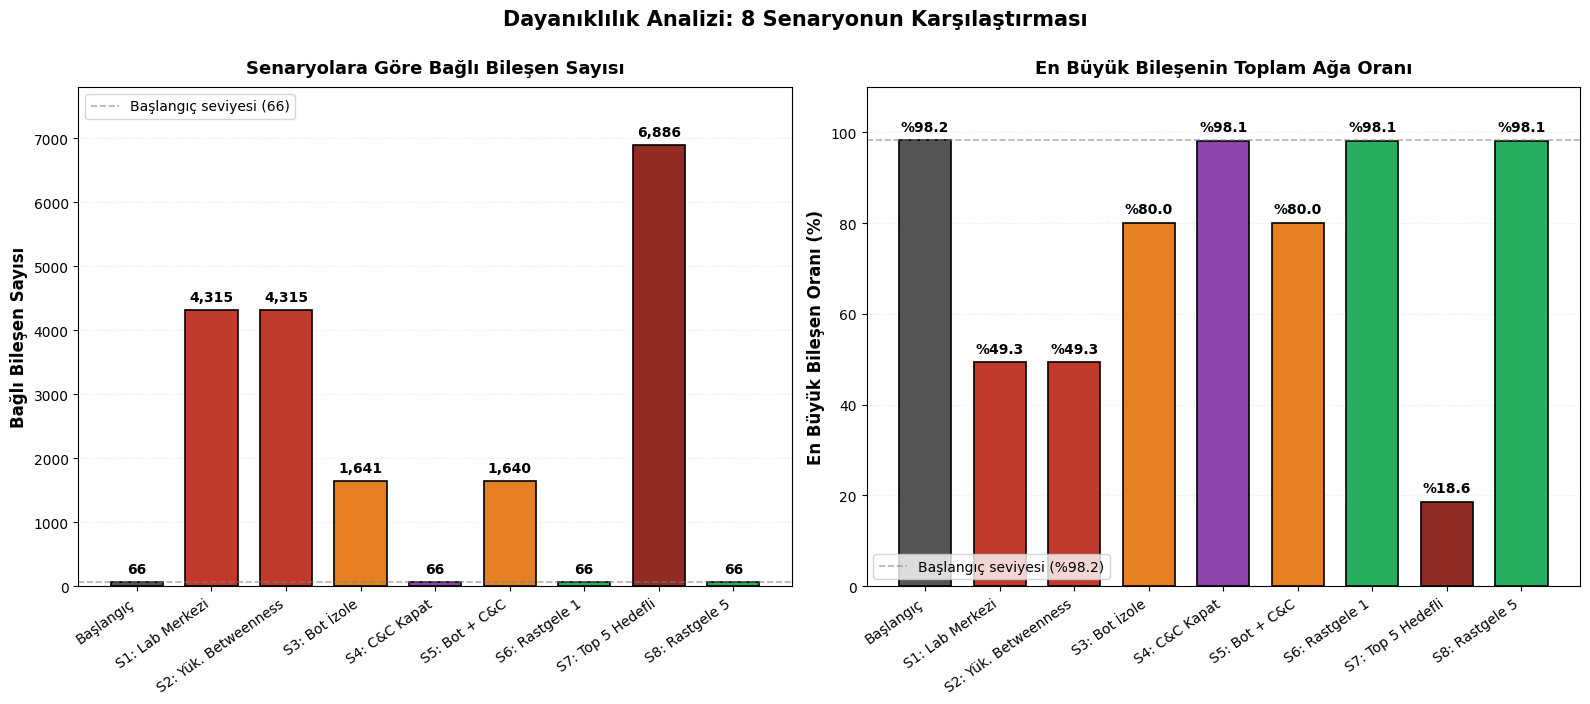


✓ Grafik kaydedildi: senaryo_bar.png


In [101]:
import matplotlib.pyplot as plt
import numpy as np

# Veri
isimler = [
    'Başlangıç',
    'S1: Lab Merkezi',
    'S2: Yük. Betweenness',
    'S3: Bot İzole',
    'S4: C&C Kapat',
    'S5: Bot + C&C',
    'S6: Rastgele 1',
    'S7: Top 5 Hedefli',
    'S8: Rastgele 5'
]
bilesen = [66, 4315, 4315, 1641, 66, 1640, 66, 6886, 66]
en_buyuk = [98.2, 49.3, 49.3, 80.0, 98.1, 80.0, 98.1, 18.6, 98.1]

# Renk: Hedefli = kırmızı tonları, Rastgele/etkisiz = yeşil, Başlangıç = gri
renkler = ['#555555',   # başlangıç
            '#C0392B',   # S1 hedefli yıkıcı
            '#C0392B',   # S2 hedefli yıkıcı
            '#E67E22',   # S3 bot izole
            '#8E44AD',   # S4 C&C
            '#E67E22',   # S5 bot+C&C
            '#27AE60',   # S6 rastgele
            '#922B21',   # S7 en yıkıcı (koyu kırmızı)
            '#27AE60']   # S8 rastgele

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# === GRAFİK 1: BİLEŞEN SAYISI ===
x_poz = np.arange(len(isimler))
bars1 = ax1.bar(x_poz, bilesen, color=renkler, edgecolor='black',
                  linewidth=1.2, width=0.7)

# Değerleri çubukların üzerine yaz
for bar, val in zip(bars1, bilesen):
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 100,
              f'{val:,}', ha='center', va='bottom',
              fontsize=10, fontweight='bold')

# Başlangıç çizgisi
ax1.axhline(y=66, color='gray', linewidth=1.2, linestyle='--', alpha=0.6,
             label='Başlangıç seviyesi (66)')

ax1.set_xticks(x_poz)
ax1.set_xticklabels(isimler, rotation=35, ha='right', fontsize=10)
ax1.set_ylabel('Bağlı Bileşen Sayısı', fontsize=12, fontweight='bold')
ax1.set_title('Senaryolara Göre Bağlı Bileşen Sayısı',
              fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle=':')
ax1.set_ylim(0, 7800)
ax1.set_axisbelow(True)

# === GRAFİK 2: EN BÜYÜK BİLEŞEN ORANI ===
bars2 = ax2.bar(x_poz, en_buyuk, color=renkler, edgecolor='black',
                  linewidth=1.2, width=0.7)

for bar, val in zip(bars2, en_buyuk):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1.5,
              f'%{val:.1f}', ha='center', va='bottom',
              fontsize=10, fontweight='bold')

ax2.axhline(y=98.2, color='gray', linewidth=1.2, linestyle='--', alpha=0.6,
             label='Başlangıç seviyesi (%98.2)')

ax2.set_xticks(x_poz)
ax2.set_xticklabels(isimler, rotation=35, ha='right', fontsize=10)
ax2.set_ylabel('En Büyük Bileşen Oranı (%)', fontsize=12, fontweight='bold')
ax2.set_title('En Büyük Bileşenin Toplam Ağa Oranı',
              fontsize=13, fontweight='bold', pad=10)
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle=':')
ax2.set_ylim(0, 110)
ax2.set_axisbelow(True)

# Genel başlık
fig.suptitle('Dayanıklılık Analizi: 8 Senaryonun Karşılaştırması',
             fontsize=15, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('senaryo_bar.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Grafik kaydedildi: senaryo_bar.png")

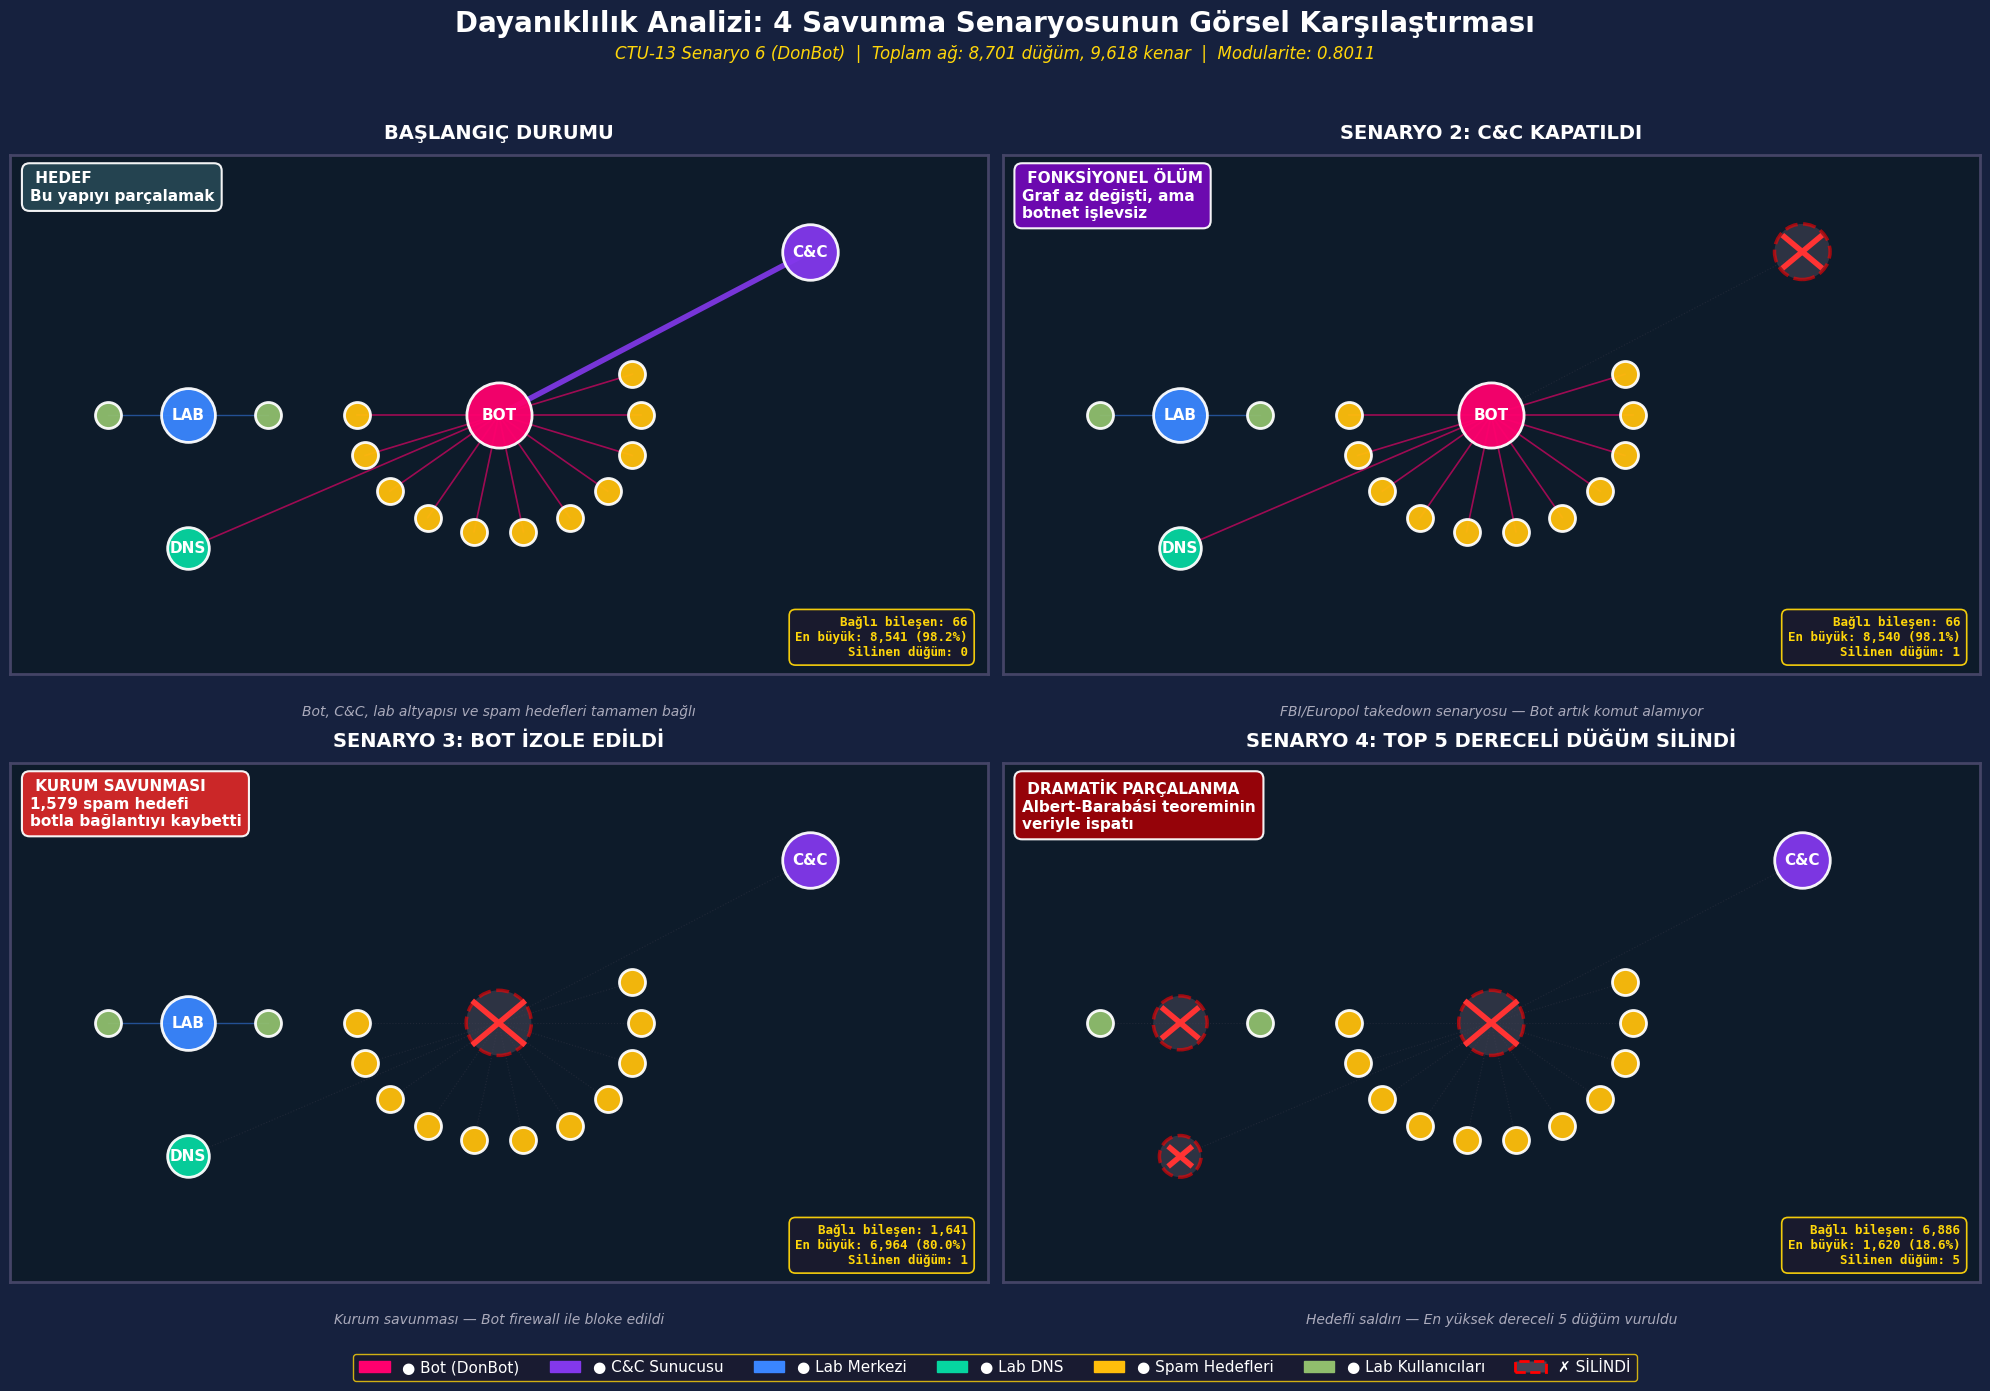


✓ Profesyonel görsel kaydedildi: senaryo_karsilastirma.png
📊 Sayısal Karşılaştırma:
   ① Başlangıç: 66 bileşen
   ② C&C kapatıldı: bot fonksiyonel olarak öldü, graf az değişti
   ③ Bot izole: 1,579 hedef koptu, ağ parçalandı
   ④ Top 5: dramatik felç — Albert-Barabási teoremi ispatlandı


In [102]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import networkx as nx
import numpy as np
import math

# === Kritik düğümler ===
bot_ip = '147.32.84.165'
cc_ip = '91.212.135.158'
lab_hub = '147.32.84.229'
lab_dns = '147.32.80.9'

G_test = G.to_undirected()

# Bot etrafındaki en yoğun 12 spam hedefi (görsel temiz olsun)
bot_komsular = sorted(G.successors(bot_ip),
                      key=lambda h: G[bot_ip][h]['weight'],
                      reverse=True)[:12]

# Lab altyapısı için 5 makine
lab_komsular = sorted([n for n in G_test.neighbors(lab_hub) if n.startswith('147.32.')],
                      key=lambda h: G_test.degree(h),
                      reverse=True)[:6]

secilen = list(set([bot_ip, cc_ip, lab_hub, lab_dns] + bot_komsular + lab_komsular))
G_v = G_test.subgraph(secilen).copy()

# === MANUEL POZİSYON ===
pos = {}

# Bot tam ortada
pos[bot_ip] = np.array([0, 0])
# C&C sağ üstte, dramatik mesafede
pos[cc_ip] = np.array([3.5, 2.2])
# Lab Hub sol tarafta
pos[lab_hub] = np.array([-3.5, 0])
# Lab DNS lab hub'ın altında
pos[lab_dns] = np.array([-3.5, -1.8])

# Spam hedefleri bot etrafında halka (alt yarımküre + sağ)
spam_hedefler = [h for h in bot_komsular if h != cc_ip and h not in pos]
n_spam = len(spam_hedefler)
for i, h in enumerate(spam_hedefler):
    aci = math.radians(180 + (i * 200 / max(n_spam-1, 1)))
    pos[h] = np.array([1.6 * math.cos(aci), 1.6 * math.sin(aci)])

# Lab komşuları lab hub etrafında küçük halka
lab_kalan = [h for h in lab_komsular if h not in pos]
for i, h in enumerate(lab_kalan):
    aci = math.radians(i * 360 / max(len(lab_kalan), 1))
    pos[h] = np.array([-3.5 + 0.9 * math.cos(aci),
                        0 + 0.9 * math.sin(aci)])

# Eksik düğümler için tamamlama
for n in G_v.nodes():
    if n not in pos:
        pos[n] = np.array([np.random.uniform(-2, 2), np.random.uniform(-2, 2)])

# === Düğüm sınıflandırma ===
def dugum_kategori(n):
    if n == bot_ip: return 'BOT'
    elif n == cc_ip: return 'CC'
    elif n == lab_hub: return 'LAB_HUB'
    elif n == lab_dns: return 'LAB_DNS'
    elif n in bot_komsular: return 'SPAM'
    else: return 'LAB_USER'

renkler = {
    'BOT':      '#FF006E',  # neon pembe
    'CC':       '#8338EC',  # canlı mor
    'LAB_HUB':  '#3A86FF',  # canlı mavi
    'LAB_DNS':  '#06D6A0',  # turkuaz
    'SPAM':     '#FFBE0B',  # neon turuncu
    'LAB_USER': '#90BE6D',  # yeşil
}
boyutlar = {'BOT':2200, 'CC':1600, 'LAB_HUB':1500, 'LAB_DNS':900,
            'SPAM':350, 'LAB_USER':350}

# === SENARYO ÇİZİM FONKSİYONU ===
def senaryo_ciz(ax, baslik, alt_baslik, silinecek_set, mesaj_baslik, mesaj_renk):
    """Tek bir senaryo alt grafiği çizer."""
    # Tam graftan silme yap (gerçek sayılar için)
    G_kopya_tam = G_test.copy()
    G_kopya_tam.remove_nodes_from(silinecek_set)
    bilesenler = list(nx.connected_components(G_kopya_tam))
    en_buyuk = max((len(c) for c in bilesenler), default=0)
    bilesen_sayisi = len(bilesenler)
    en_buyuk_oran = en_buyuk / G_test.number_of_nodes() * 100

    # Koyu arka plan
    ax.set_facecolor('#0d1b2a')

    # === KENARLAR ===
    for u, v in G_v.edges():
        if u in silinecek_set or v in silinecek_set:
            # Silinmiş kenar — soluk kesik
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color='#3a3a4a', linewidth=0.8, linestyle=':',
                    alpha=0.4, zorder=1)
        else:
            # C&C-Bot özel kenar
            if {u, v} == {bot_ip, cc_ip}:
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#8338EC', linewidth=4, alpha=0.9, zorder=2)
            elif u == bot_ip or v == bot_ip:
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#FF006E', linewidth=1.2, alpha=0.6, zorder=2)
            elif u == lab_hub or v == lab_hub:
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#3A86FF', linewidth=1.0, alpha=0.5, zorder=2)
            else:
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#555566', linewidth=0.5, alpha=0.3, zorder=1)

    # === DÜĞÜMLER ===
    for n in G_v.nodes():
        kat = dugum_kategori(n)
        x, y = pos[n]

        if n in silinecek_set:
            # SİLİNMİŞ — gri, kesik kenarlık, X işareti
            ax.scatter(x, y, s=boyutlar[kat], c='#444455', edgecolors='red',
                       linewidths=2.5, linestyle='--', zorder=3, alpha=0.6)
            # Büyük kırmızı X
            offset = boyutlar[kat] / 8000
            ax.plot([x-offset, x+offset], [y-offset, y+offset],
                    color='#FF3333', linewidth=4, zorder=10)
            ax.plot([x-offset, x+offset], [y+offset, y-offset],
                    color='#FF3333', linewidth=4, zorder=10)
        else:
            # NORMAL düğüm
            ax.scatter(x, y, s=boyutlar[kat], c=renkler[kat],
                       edgecolors='white', linewidths=2, zorder=3, alpha=0.95)

    # === Etiketler (önemli düğümler) ===
    onemli = {bot_ip: 'BOT', cc_ip: 'C&C', lab_hub: 'LAB', lab_dns: 'DNS'}
    for ip, lbl in onemli.items():
        if ip in pos:
            x, y = pos[ip]
            if ip not in silinecek_set:
                ax.text(x, y, lbl, ha='center', va='center',
                        fontsize=11, fontweight='bold', color='white',
                        zorder=11)

    # === Başlık ===
    ax.set_title(baslik, fontsize=14, fontweight='bold',
                 color='white', pad=12)

    # === Alt başlık (senaryo açıklaması) ===
    ax.text(0.5, -0.08, alt_baslik, transform=ax.transAxes,
            ha='center', fontsize=10, style='italic', color='#aaaabb')

    # === MESAJ KUTUSU (sol üst) ===
    ax.text(0.02, 0.97, mesaj_baslik, transform=ax.transAxes,
            fontsize=11, fontweight='bold', verticalalignment='top',
            color='white',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=mesaj_renk,
                      edgecolor='white', linewidth=1.5, alpha=0.95))

    # === SAYISAL KUTU (sağ alt) ===
    metric_text = (f"Bağlı bileşen: {bilesen_sayisi:,}\n"
                   f"En büyük: {en_buyuk:,} ({en_buyuk_oran:.1f}%)\n"
                   f"Silinen düğüm: {len(silinecek_set)}")
    ax.text(0.98, 0.03, metric_text, transform=ax.transAxes,
            fontsize=9, fontweight='bold', verticalalignment='bottom',
            horizontalalignment='right', color='#FFD60A',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#1a1a2e',
                      edgecolor='#FFD60A', linewidth=1.2, alpha=0.95))

    ax.set_xlim(-5.5, 5.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#444466')
        spine.set_linewidth(2)

# === FİGÜR ===
fig = plt.figure(figsize=(20, 14), facecolor='#16213e')

# 4 alt grafik
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 2, 3)
ax4 = plt.subplot(2, 2, 4)

# === SENARYO 1: BAŞLANGIÇ ===
senaryo_ciz(ax1,
    'BAŞLANGIÇ DURUMU',
    'Bot, C&C, lab altyapısı ve spam hedefleri tamamen bağlı',
    set(),
    ' HEDEF\nBu yapıyı parçalamak',
    '#264653')

# === SENARYO 2: C&C kapatıldı (FBI Takedown) ===
senaryo_ciz(ax2,
    'SENARYO 2: C&C KAPATILDI',
    'FBI/Europol takedown senaryosu — Bot artık komut alamıyor',
    {cc_ip},
    ' FONKSİYONEL ÖLÜM\nGraf az değişti, ama\nbotnet işlevsiz',
    '#7209B7')

# === SENARYO 3: Bot izole ===
senaryo_ciz(ax3,
    'SENARYO 3: BOT İZOLE EDİLDİ',
    'Kurum savunması — Bot firewall ile bloke edildi',
    {bot_ip},
    ' KURUM SAVUNMASI\n1,579 spam hedefi\nbotla bağlantıyı kaybetti',
    '#D62828')

# === SENARYO 4: Top 5 dereceli ===
top_5 = [ip for ip, _ in sorted(dict(G.degree()).items(),
                                  key=lambda x: x[1], reverse=True)[:5]]
senaryo_ciz(ax4,
    'SENARYO 4: TOP 5 DERECELİ DÜĞÜM SİLİNDİ',
    'Hedefli saldırı — En yüksek dereceli 5 düğüm vuruldu',
    set(top_5),
    ' DRAMATİK PARÇALANMA\nAlbert-Barabási teoreminin\nveriyle ispatı',
    '#9D0208')

# === GENEL BAŞLIK ===
fig.suptitle('Dayanıklılık Analizi: 4 Savunma Senaryosunun Görsel Karşılaştırması',
             fontsize=20, fontweight='bold', color='white', y=0.98)

# Alt başlık
fig.text(0.5, 0.945,
         'CTU-13 Senaryo 6 (DonBot)  |  Toplam ağ: 8,701 düğüm, 9,618 kenar  |  Modularite: 0.8011',
         ha='center', fontsize=12, color='#FFD60A', style='italic')

# === Lejant (alt) ===
lejant_ogeleri = [
    mpatches.Patch(color='#FF006E', label='● Bot (DonBot)'),
    mpatches.Patch(color='#8338EC', label='● C&C Sunucusu'),
    mpatches.Patch(color='#3A86FF', label='● Lab Merkezi'),
    mpatches.Patch(color='#06D6A0', label='● Lab DNS'),
    mpatches.Patch(color='#FFBE0B', label='● Spam Hedefleri'),
    mpatches.Patch(color='#90BE6D', label='● Lab Kullanıcıları'),
    mpatches.Patch(facecolor='#444455', edgecolor='red',
                    linestyle='--', linewidth=2, label='✗ SİLİNDİ'),
]
fig.legend(handles=lejant_ogeleri, loc='lower center', ncol=7,
           fontsize=11, frameon=True, facecolor='#1a1a2e',
           edgecolor='#FFD60A', labelcolor='white',
           bbox_to_anchor=(0.5, -0.005))

plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig('senaryo_karsilastirma.png', dpi=200,
            bbox_inches='tight', facecolor='#16213e')
plt.show()

print("\n✓ Profesyonel görsel kaydedildi: senaryo_karsilastirma.png")
print(f"📊 Sayısal Karşılaştırma:")
print(f"   ① Başlangıç: 66 bileşen")
print(f"   ② C&C kapatıldı: bot fonksiyonel olarak öldü, graf az değişti")
print(f"   ③ Bot izole: 1,579 hedef koptu, ağ parçalandı")
print(f"   ④ Top 5: dramatik felç — Albert-Barabási teoremi ispatlandı")